# SI classification (> 8)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     StratifiedKFold,)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, roc_auc_score,
                             classification_report, confusion_matrix)

In [ ]:
df = pd.read_csv('/content/df.csv')

In [ ]:
df.head()

,IC50,CC50,SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,IC50_log,CC50_log,SI_log
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [ ]:
logs = [col for col in df.columns if col.endswith('_log')]

df = df.drop(columns=logs, errors='ignore')

print(f"Удалено колонок: {len(logs)}")
print("Оставшиеся признаки:", df.shape[1])

Удалено колонок: 3
Оставшиеся признаки: 155


In [ ]:
df.shape

(969, 155)

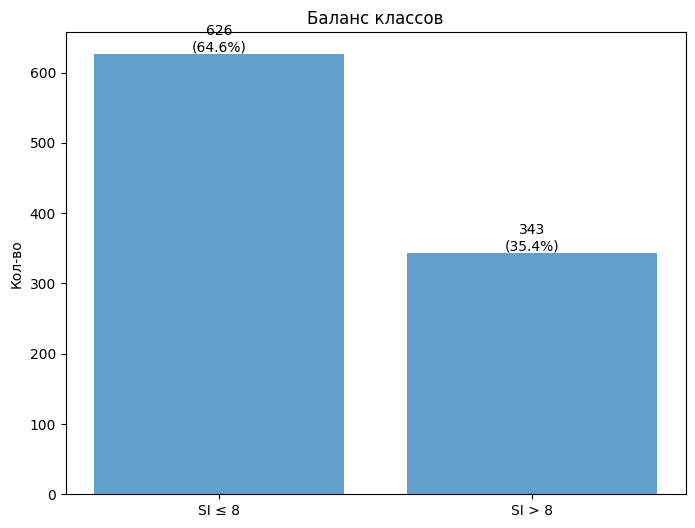

SI > 8: 35.4%
SI ≤ 8: 64.6%


In [ ]:
df['SI_above_8'] = (df['SI'] > 8).astype(int)

counts = df['SI_above_8'].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ['SI ≤ 8', 'SI > 8'],
    counts.values,
    alpha=0.7
)

plt.title('Баланс классов')
plt.ylabel('Кол-во')

for i, (c, p) in enumerate(zip(counts.values, percent.values)):
    plt.text(
        i,
        c,
        f'{c}\n({p:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.show()

print(f'SI > 8: {percent[1]:.1f}%')
print(f'SI ≤ 8: {percent[0]:.1f}%')

## Важно не пропустить перспективных соединений - попробовал сместить порог классификации для увеличения Recall

,Model,Recall,Precision,F1,ROC_AUC,Accuracy,Threshold
0,XGBoost,0.74,0.55,0.63,0.77,0.69,0.45
1,LogReg,0.65,0.45,0.54,0.67,0.60,0.45
2,RandomForest,0.64,0.58,0.61,0.76,0.71,0.45


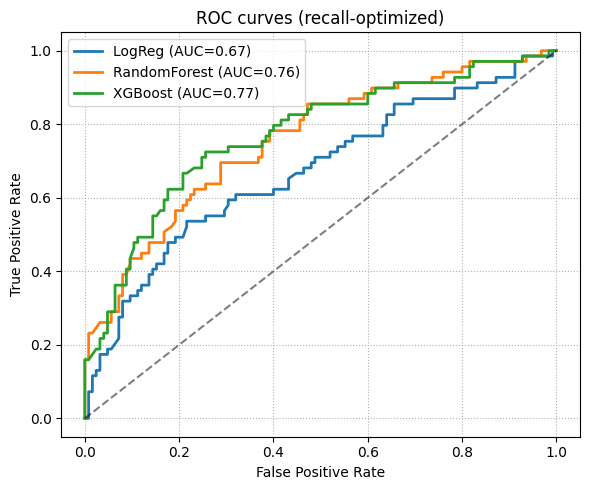

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y = df['SI_above_8']

X = df.drop(columns=['IC50','CC50',
                     'SI','SI_above_8'],
            errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

models = {
    'LogReg': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=3000,
                solver='liblinear',
                class_weight='balanced'))]),
        {
            'model__C': [0.05, 0.1, 1, 5],
            'model__penalty': ['l1', 'l2']},
        'grid'),

    'RandomForest': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight='balanced'))]),
        {
            'model__n_estimators': [250, 400],
            'model__max_depth': [None, 16],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2]},
        'random'),

    'XGBoost': (
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('model', XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight))]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.7, 0.85],
            'model__colsample_bytree': [0.7, 1.0]},
        'random')}

results = []
best_models = {}

for name, (pipe, params, kind) in models.items():

    search = (
        GridSearchCV(
            pipe,
            params,
            cv=cv,
            scoring='recall',
            n_jobs=-1)
        if kind == 'grid'
        else RandomizedSearchCV(
            pipe,
            params,
            n_iter=10,
            cv=cv,
            scoring='recall',
            n_jobs=-1,
            random_state=42))

    search.fit(X_train, y_train)

    model = search.best_estimator_

    y_score = model.predict_proba(X_test)[:, 1]

    # lower threshold → higher recall
    threshold = 0.45
    y_pred = (y_score >= threshold).astype(int)

    results.append({
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_score),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Threshold': threshold})

    best_models[name] = model

df_res = (
    pd.DataFrame(results)
    .sort_values('Recall', ascending=False)
    .round(2)
    .reset_index(drop=True))

display(df_res)

plt.figure(figsize=(6, 5))

for name, model in best_models.items():

    y_score = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.title('ROC curves (recall-optimized)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

## Интерпретация результатов моделей
- XGBoost	показал лучшие результаты всех метрик